In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


In [42]:
! pip install statsmodels

In [43]:
df= pd.read_csv("D:/Codveda Technologies project/Umair-L2-TASK-2 TimeSeriesAnalysis/2) Stock Prices Data Set.csv")

In [44]:
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  str    
 1   date    497472 non-null  str    
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 26.6 MB


In [46]:
df.describe()

,open,high,low,close,volume
count,497461.000000,497464.000000,497464.000000,497472.000000,4.974720e+05
mean,86.352275,87.132562,85.552467,86.369082,4.253611e+06
std,101.471228,102.312062,100.570957,101.472407,8.232139e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,64.970000,65.560000,64.353700,64.980000,2.084896e+06
75%,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [47]:
df.isnull().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

In [48]:
df.shape

(497472, 7)

In [49]:
df = df.drop_duplicates()

print("Duplicates after cleaning:", df.duplicated().sum())

Duplicates after cleaning: 0


In [50]:
df.isnull().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

In [51]:
df[df[["open", "high", "low",]].isnull().any(axis=1)]

,symbol,date,open,high,low,close,volume
166348,VRTX,2015-05-12,NaN,NaN,NaN,124.0800,569747
175557,REGN,2015-06-09,NaN,NaN,NaN,526.0900,12135
182011,WRK,2015-06-26,NaN,NaN,NaN,61.9000,100
188547,DHR,2015-07-17,NaN,88.76,88.24,88.7200,2056819
188578,ES,2015-07-17,NaN,48.49,47.85,47.9200,1246786
188760,O,2015-07-17,NaN,47.31,46.83,46.9900,1229513
249223,DHR,2016-01-12,NaN,NaN,NaN,88.5500,0
249438,O,2016-01-12,NaN,NaN,NaN,52.4300,0
278801,UA,2016-04-07,NaN,NaN,NaN,41.5600,0
308365,FTV,2016-07-01,NaN,NaN,NaN,49.5400,0


In [52]:
df = df.dropna(subset=['open', 'high', 'low'])

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [53]:
# convert date and time column to datetime format

df['date'] = pd.to_datetime(df['date'])

print(df.dtypes)

df = df.sort_values(['symbol', 'date'])

display(df.head())

symbol               str
date      datetime64[us]
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object


,symbol,date,open,high,low,close,volume
57,A,2014-01-02,57.10,57.100,56.15,56.21,1916160
540,A,2014-01-03,56.39,57.345,56.26,56.92,1866651
1023,A,2014-01-06,57.40,57.700,56.56,56.64,1777472
1506,A,2014-01-07,56.95,57.630,56.93,57.45,1463208
1989,A,2014-01-08,57.33,58.540,57.17,58.39,2659468


In [54]:
stock = df[df['symbol'] == 'AAPL'].copy()

print("Number of AAPL rows:", len(stock))
print("Symbol:", stock['symbol'].unique())

display(stock.head())

Number of AAPL rows: 1007
Symbol: <StringArray>
['AAPL']
Length: 1, dtype: str


,symbol,date,open,high,low,close,volume
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
484,AAPL,2014-01-03,78.9799,79.0999,77.2042,77.2828,98303870
967,AAPL,2014-01-06,76.7785,78.1142,76.2285,77.7042,103359151
1450,AAPL,2014-01-07,77.7599,77.9942,76.8464,77.1481,79432766
1933,AAPL,2014-01-08,76.9728,77.9371,76.9556,77.6371,64686685


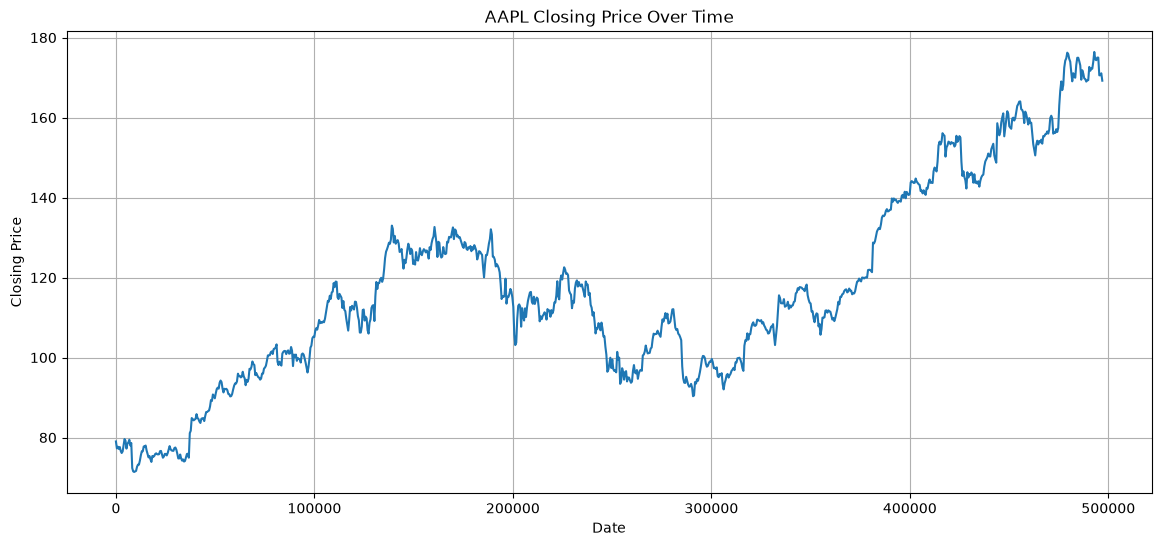

In [55]:
# plot the stock price
 
plt.figure(figsize=(14, 6))

plt.plot(stock.index, stock['close'])

plt.title('AAPL Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.grid(True)
plt.show()

In [56]:
# 2. Decompose the series into trend, seasonality, and residuals using statsmodels.
print(stock.head())
print(stock.columns)
print(stock.shape)
print(stock['close'].dtype)
print(stock['close'].isnull().sum())


     symbol       date     open     high      low    close     volume
1      AAPL 2014-01-02  79.3828  79.5756  78.8601  79.0185   58791957
484    AAPL 2014-01-03  78.9799  79.0999  77.2042  77.2828   98303870
967    AAPL 2014-01-06  76.7785  78.1142  76.2285  77.7042  103359151
1450   AAPL 2014-01-07  77.7599  77.9942  76.8464  77.1481   79432766
1933   AAPL 2014-01-08  76.9728  77.9371  76.9556  77.6371   64686685
Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume'], dtype='str')
(1007, 7)
float64
0


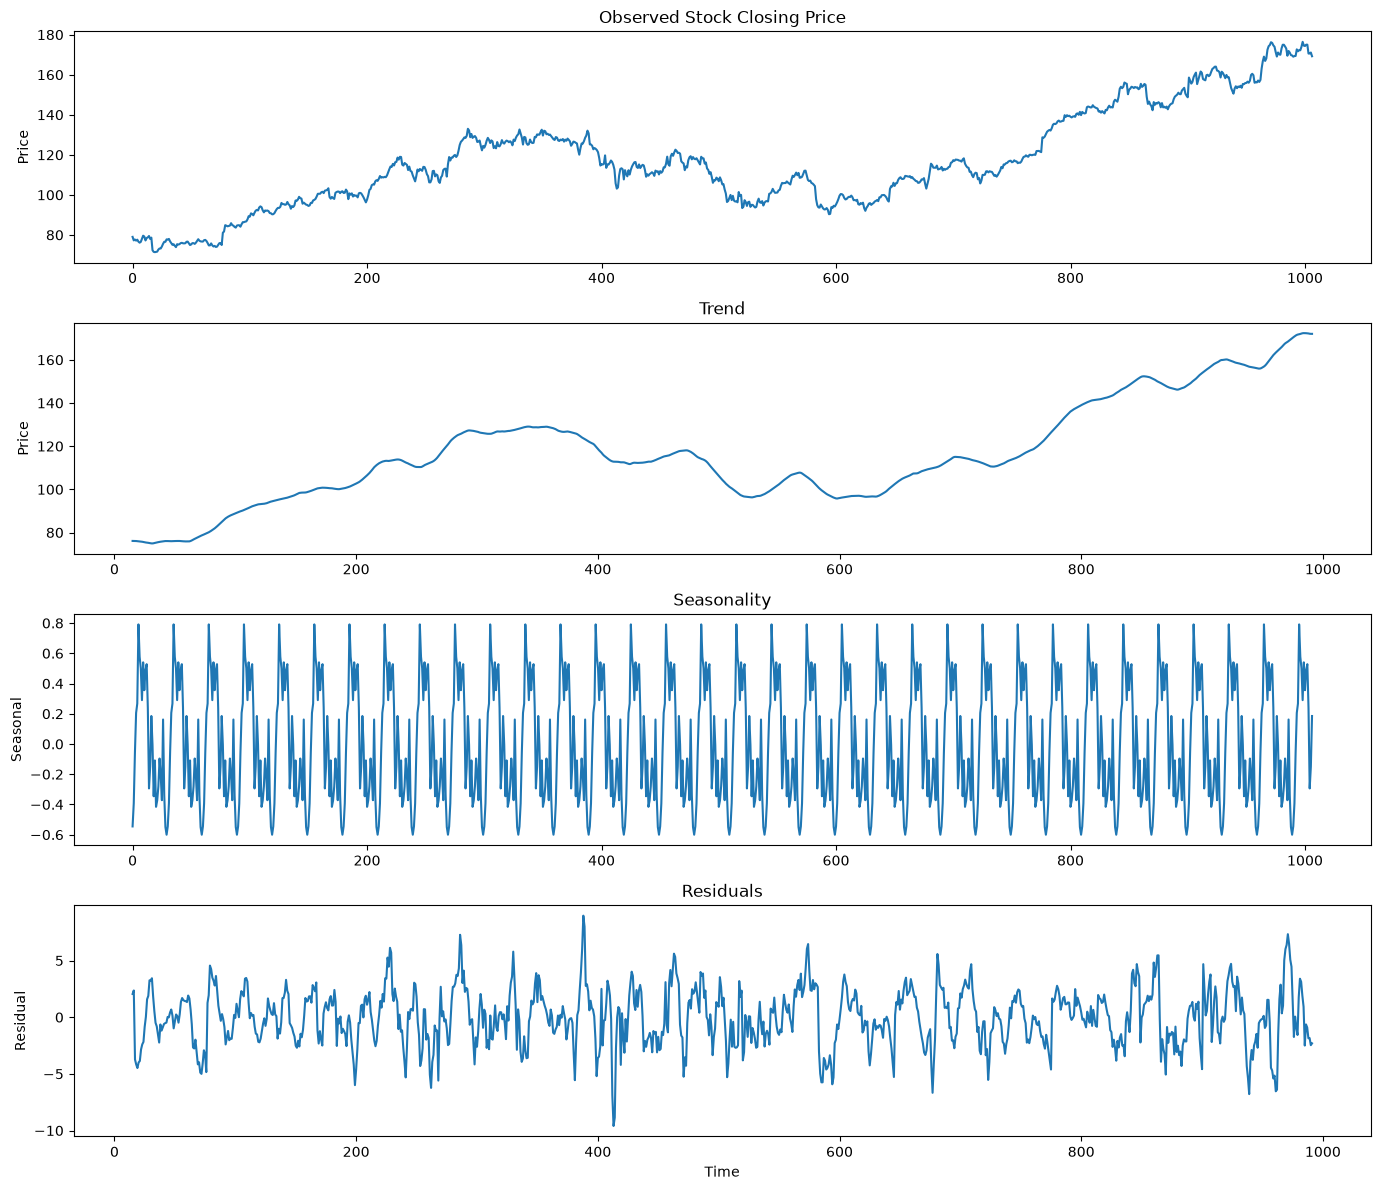

Decomposition completed successfully.


In [57]:
#2: Decompose the series into trend, seasonality, and residuals using statsmodels.

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

prices = stock["close"].to_numpy(dtype=float)

# Remove any missing or infinite values
prices = prices[np.isfinite(prices)]

decomposition = seasonal_decompose(
    prices,
    model="additive",
    period=30
)


# Create the plots
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

axes[0].plot(decomposition.observed)
axes[0].set_title("Observed Stock Closing Price")
axes[0].set_ylabel("Price")


axes[1].plot(decomposition.trend)
axes[1].set_title("Trend")
axes[1].set_ylabel("Price")


axes[2].plot(decomposition.seasonal)
axes[2].set_title("Seasonality")
axes[2].set_ylabel("Seasonal")


axes[3].plot(decomposition.resid)
axes[3].set_title("Residuals")
axes[3].set_ylabel("Residual")
axes[3].set_xlabel("Time")

plt.tight_layout()
plt.show()

print("Decomposition completed successfully.")

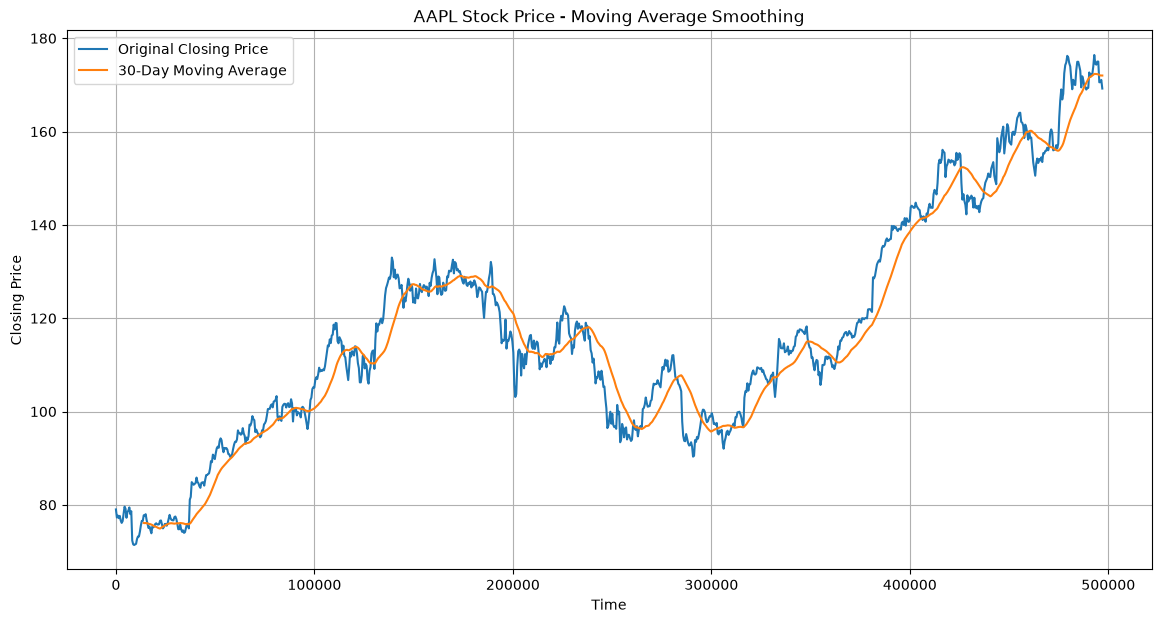

In [58]:
# 3. Perform moving average smoothing and plot the results

moving_average = stock['close'].rolling(window=30).mean()

plt.figure(figsize=(14, 7))

plt.plot(stock['close'], label='Original Closing Price')
plt.plot(moving_average, label='30-Day Moving Average')

plt.title('AAPL Stock Price - Moving Average Smoothing')
plt.xlabel('Time')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(True)

plt.show()